<div class="alert alert-danger" role="alert">
<h1 align="center"><font size = 14>Deep-Learning (Part2)</font></h1>
<h4 align="center">Aug, 09_2026<h4>
<h3 align="center">Armin Amani</h3>

<div class="alert alert-danger" role="alert">
📤 Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

In [2]:
np.random.seed(42)
tf.random.set_seed(42)

<div class="alert alert-danger" role="alert"> 
💾 Read Data

In [3]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

In [4]:
print(f"shape of X_train is : {X_train.shape}")
print(f"shape of y_train is : {y_train.shape}")
print(f"shape of X_test is : {X_test.shape}")
print(f"shape of y_test is : {y_test.shape}")

shape of X_train is : (50000, 32, 32, 3)
shape of y_train is : (50000, 1)
shape of X_test is : (10000, 32, 32, 3)
shape of y_test is : (10000, 1)


<div class="alert alert-danger" role="alert"> 
🔎 normalize x_train and x_test

In [5]:
X_train = X_train / 255.0
X_test = X_test / 255.0

<div class="alert alert-danger" role="alert"> 
🔎 OHE

In [6]:
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

In [7]:
y_train[1]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.], dtype=float32)

<div class="alert alert-danger" role="alert"> 
🔎 build the neural network model

In [8]:
model1 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(32, 32, 3)),
    tf.keras.layers.Dense(128, activation=tf.keras.layers.LeakyReLU(alpha=0.01)),
    tf.keras.layers.Dense(64, activation=tf.keras.layers.LeakyReLU(alpha=0.01)),
    tf.keras.layers.Dense(32, activation=tf.keras.layers.LeakyReLU(alpha=0.01)),
    tf.keras.layers.Dense(16, activation=tf.keras.layers.LeakyReLU(alpha=0.01)),
    tf.keras.layers.Dense(10, activation='softmax'),
])

In [9]:
model1.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 3072)              0         
                                                                 
 dense (Dense)               (None, 128)               393344    
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dense_3 (Dense)             (None, 16)                528       
                                                                 
 dense_4 (Dense)             (None, 10)                170       
                                                                 
Total params: 404,378
Trainable params: 404,378
Non-trai

In [10]:
model2 = tf.keras.Sequential([(
    tf.keras.layers.Flatten(input_shape=(32, 32, 3))),
    tf.keras.layers.Dense(256, activation=tf.keras.layers.LeakyReLU(alpha=0.01)),
    tf.keras.layers.Dense(128, activation=tf.keras.layers.LeakyReLU(alpha=0.01)),
    tf.keras.layers.Dense(64, activation=tf.keras.layers.LeakyReLU(alpha=0.01)),
    tf.keras.layers.Dense(32, activation=tf.keras.layers.LeakyReLU(alpha=0.01)),
    tf.keras.layers.Dense(16, activation=tf.keras.layers.LeakyReLU(alpha=0.01)),
    tf.keras.layers.Dense(10, activation='softmax')
])

In [11]:
model2.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_1 (Flatten)         (None, 3072)              0         
                                                                 
 dense_5 (Dense)             (None, 256)               786688    
                                                                 
 dense_6 (Dense)             (None, 128)               32896     
                                                                 
 dense_7 (Dense)             (None, 64)                8256      
                                                                 
 dense_8 (Dense)             (None, 32)                2080      
                                                                 
 dense_9 (Dense)             (None, 16)                528       
                                                                 
 dense_10 (Dense)            (None, 10)               

<div class="alert alert-danger" role="alert"> 
🔎 compile the model

In [12]:
model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [13]:
model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

<div class="alert alert-danger" role="alert"> 
🔎 train the model

In [14]:
history1 = model1.fit(X_train, y_train, epochs=100, batch_size=16, validation_split=0.3)

Epoch 1/100
2188/2188 [==============================] - 5s 2ms/step - loss: 1.9779 - accuracy: 0.2621 - val_loss: 1.8745 - val_accuracy: 0.3250
Epoch 2/100
2188/2188 [==============================] - 5s 2ms/step - loss: 1.8063 - accuracy: 0.3422 - val_loss: 1.7946 - val_accuracy: 0.3422
Epoch 3/100
2188/2188 [==============================] - 4s 2ms/step - loss: 1.7407 - accuracy: 0.3702 - val_loss: 1.7528 - val_accuracy: 0.3680
Epoch 4/100
2188/2188 [==============================] - 4s 2ms/step - loss: 1.6845 - accuracy: 0.3897 - val_loss: 1.6870 - val_accuracy: 0.3961
Epoch 5/100
2188/2188 [==============================] - 4s 2ms/step - loss: 1.6481 - accuracy: 0.4056 - val_loss: 1.6497 - val_accuracy: 0.4058
Epoch 6/100
2188/2188 [==============================] - 4s 2ms/step - loss: 1.6141 - accuracy: 0.4184 - val_loss: 1.6528 - val_accuracy: 0.4121
Epoch 7/100
2188/2188 [==============================] - 5s 2ms/step - loss: 1.5913 - accuracy: 0.4279 - val_loss: 1.6715 - val_ac

In [15]:
history2 = model2.fit(X_train, y_train, epochs=100, batch_size=16, validation_split=0.3)

Epoch 1/100
2188/2188 [==============================] - 9s 4ms/step - loss: 2.0145 - accuracy: 0.2383 - val_loss: 1.9474 - val_accuracy: 0.2778
Epoch 2/100
2188/2188 [==============================] - 9s 4ms/step - loss: 1.8422 - accuracy: 0.3223 - val_loss: 1.8782 - val_accuracy: 0.3158
Epoch 3/100
2188/2188 [==============================] - 9s 4ms/step - loss: 1.7571 - accuracy: 0.3643 - val_loss: 1.7573 - val_accuracy: 0.3643
Epoch 4/100
2188/2188 [==============================] - 9s 4ms/step - loss: 1.6985 - accuracy: 0.3847 - val_loss: 1.7291 - val_accuracy: 0.3711
Epoch 5/100
2188/2188 [==============================] - 8s 4ms/step - loss: 1.6603 - accuracy: 0.4014 - val_loss: 1.6537 - val_accuracy: 0.4085
Epoch 6/100
2188/2188 [==============================] - 8s 4ms/step - loss: 1.6254 - accuracy: 0.4181 - val_loss: 1.7423 - val_accuracy: 0.3809
Epoch 7/100
2188/2188 [==============================] - 8s 4ms/step - loss: 1.5884 - accuracy: 0.4303 - val_loss: 1.5975 - val_ac

<div class="alert alert-danger" role="alert"> 
🔎 evaluate the model

In [16]:
y_test_arg1=np.argmax(y_test,axis=1)
y_pred1 = np.argmax(model1.predict(X_test),axis=1)
print(classification_report(y_true=y_test_arg1, y_pred=y_pred1))

313/313 [==============================] - 1s 1ms/step
              precision    recall  f1-score   support

           0       0.49      0.61      0.54      1000
           1       0.61      0.52      0.56      1000
           2       0.39      0.29      0.33      1000
           3       0.31      0.40      0.35      1000
           4       0.43      0.37      0.40      1000
           5       0.42      0.32      0.36      1000
           6       0.48      0.57      0.52      1000
           7       0.59      0.48      0.53      1000
           8       0.58      0.61      0.60      1000
           9       0.49      0.61      0.54      1000

    accuracy                           0.48     10000
   macro avg       0.48      0.48      0.47     10000
weighted avg       0.48      0.48      0.47     10000



In [17]:
y_test_arg2 = np.argmax(y_test,axis=1)
y_pred2 = np.argmax(model2.predict(X_test), axis=1)
print(classification_report(y_true=y_test_arg2, y_pred=y_pred2))

313/313 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0       0.50      0.60      0.55      1000
           1       0.59      0.57      0.58      1000
           2       0.47      0.29      0.35      1000
           3       0.29      0.46      0.36      1000
           4       0.47      0.33      0.39      1000
           5       0.38      0.29      0.33      1000
           6       0.47      0.60      0.53      1000
           7       0.60      0.46      0.52      1000
           8       0.60      0.63      0.61      1000
           9       0.52      0.55      0.53      1000

    accuracy                           0.48     10000
   macro avg       0.49      0.48      0.47     10000
weighted avg       0.49      0.48      0.47     10000



<div class="alert alert-danger" role="alert"> 
⬛⬜⬛⬜⬛⬜ Plot

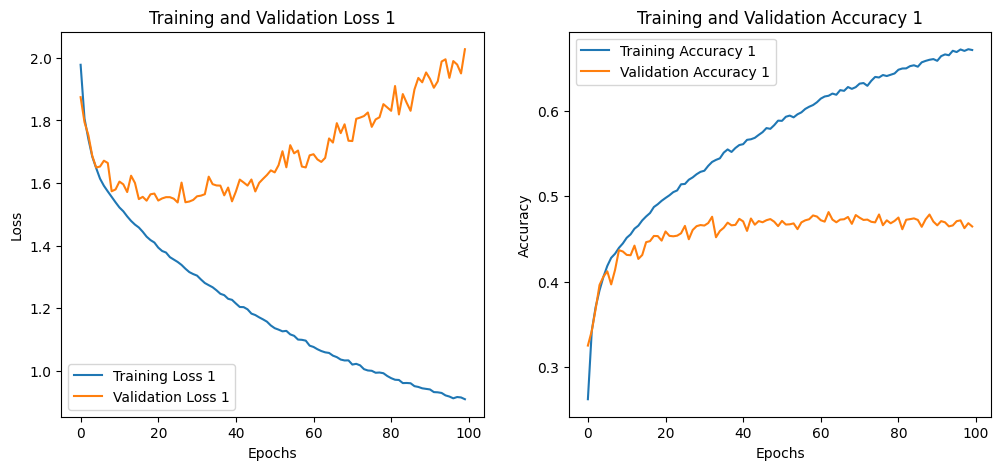

In [18]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history1.history['loss'], label='Training Loss 1')
plt.plot(history1.history['val_loss'], label='Validation Loss 1')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss 1')

plt.subplot(1, 2, 2)
plt.plot(history1.history['accuracy'], label='Training Accuracy 1')
plt.plot(history1.history['val_accuracy'], label='Validation Accuracy 1')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy 1')

plt.show()

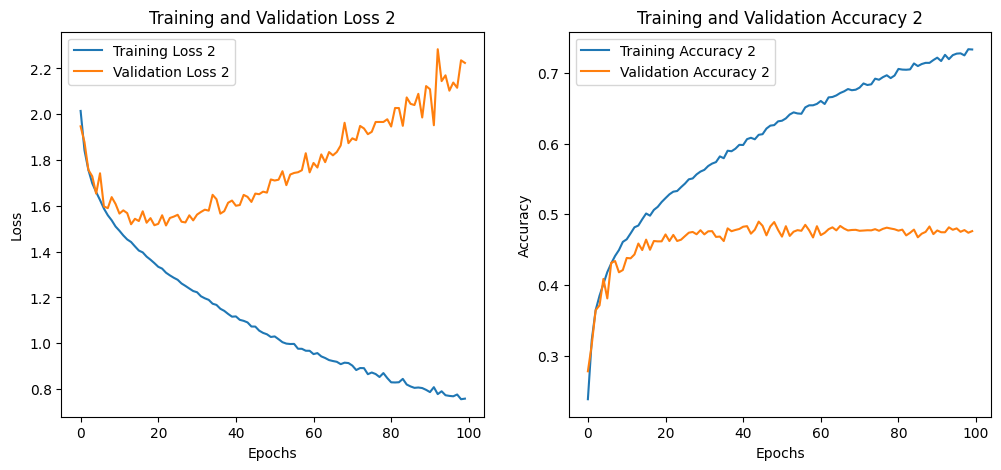

In [19]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history2.history['loss'], label='Training Loss 2')
plt.plot(history2.history['val_loss'], label='Validation Loss 2')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss 2')

plt.subplot(1, 2, 2)
plt.plot(history2.history['accuracy'], label='Training Accuracy 2')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy 2')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy 2')

plt.show()